In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
from scipy.cluster import hierarchy
from tem import world, model
from pathlib import Path
import itertools
import polars as pl
import seaborn as sns
import torch
from tbparse import SummaryReader
config_file = "../envs/mckenzie2024.json"
out_dir = Path("~/Dropbox/work/tem/McKenzie").expanduser() / "study-12"
fig_dir = out_dir / "figs"
fig_dir.mkdir(exist_ok=True, parents=True)

In [2]:
design = world.design_mckenzie(config_file, {"AB": 400, "CD": 400, "ABCD": 400})
node_tuples = (
    [c for c in itertools.product(["C1", "C2"], ["AB", "BA", "CD", "DC"])]
    + [c for c in itertools.product(["C1", "C2"], ["L", "R"], ["A", "B", "C", "D"], ["R", "N"])]
)
node_features = []
for tup in node_tuples:
    if len(tup) == 2:
        features = {"context": tup[0], "objects": tup[1]}
    else:
        features = {"context": tup[0], "choice": tup[1], "object": tup[2], "valence": tup[3]}
    node_features.append(features)

node_labels = ["".join(c) for c in node_tuples]

In [3]:
df = pl.DataFrame(node_features)
n = df.select(pl.all().drop_nulls().n_unique())
n_features = {s.name: s[0] for s in n.iter_columns()}
i = len(node_labels)
features = {}
for key, val in n_features.items():
    features[key] = {"start": i, "items": df[key].drop_nulls().unique().to_list()}
    i += val

In [4]:
n_runs = 1
for run in range(1, n_runs + 1):
    world.learn_mckenzie(design, node_labels, node_features, features, out_dir, run)

In [5]:
param_file = out_dir / "sub-001_run-1_params.pt"
params = torch.load(param_file, weights_only=False)
tem_model = model.Model(params)
walks = world.walks_mckenzie(design, node_labels, node_features, features, params["n_x"])

g_state = []
p_state = []
with torch.no_grad():
    for walk in walks:
        forward = tem_model(walk, prev_iter=None)
        for step in forward:
            g_module = []
            p_module = []
            # g_module.append(step.g_inf[-1][0].numpy())
            for f in range(tem_model.hyper["n_f"]):
                g_module.append(step.g_inf[f][0].numpy())
                p_module.append(step.p_inf[f][0].numpy())
            g_state.append(np.concat(g_module))
            p_state.append(np.concat(p_module))
g = np.vstack(g_state)
p = np.vstack(p_state)

In [6]:
subject = "001"
reader = SummaryReader(str(out_dir))
df = (
    pl.DataFrame(reader.scalars)
    .with_columns(
        subject=pl.lit(subject),
        run=pl.col("value").cum_count().over(pl.col("step")),
        phase=(
            pl.when(pl.col("step") < 400)
            .then(pl.lit("AB"))
            .when((pl.col("step") >= 400) & (pl.col("step") < 800))
            .then(pl.lit("CD"))
            .when(pl.col("step") >= 800)
            .then(pl.lit("ABCD"))
        )
    )
    .with_columns(
        trial=pl.col("step").cum_count().over("phase"),
        smooth_value=pl.col("value").rolling_mean(window_size=50).over("tag", "run", "phase"),
    )
)

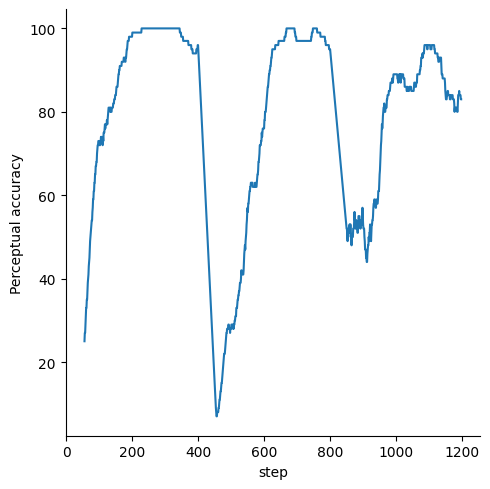

In [7]:
h = sns.relplot(
    df.filter(pl.col("tag") == "Accuracies/p"),
    x="step",
    y="smooth_value",
    kind="line",
)
h.set(ylabel="Perceptual accuracy")

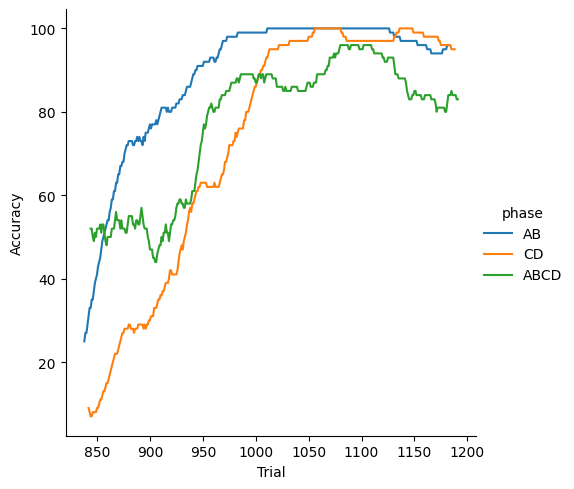

In [8]:
h = sns.relplot(
    df.filter(pl.col("tag") == "Accuracies/p"),
    x="trial",
    y="smooth_value",
    hue="phase",
    kind="line",
)
h.set(xlabel="Trial", ylabel="Accuracy")
h.savefig(fig_dir / "learning.pdf")

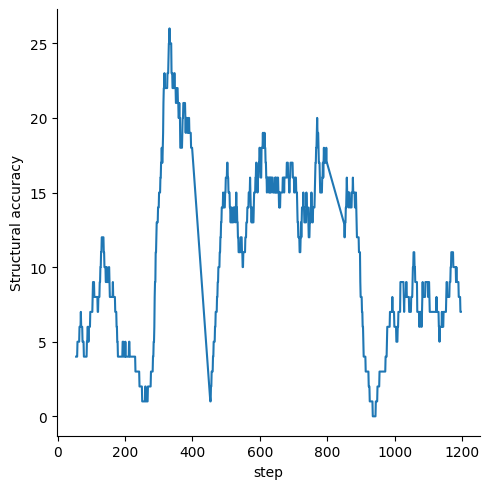

In [9]:
h = sns.relplot(
    df.filter(pl.col("tag") == "Accuracies/g"),
    x="step",
    y="smooth_value",
    kind="line",
)
h.set(ylabel="Structural accuracy")

In [10]:
nodes = (
    design.with_row_index("iteration")
    .filter(trial_type="feedback")
    .unique("node", keep="last")
    .sort("context", "action", "object_set", "object")
)
nodes

iteration,index,phase,trial,context,object_set,node,action,object,valence,trial_type
u32,u32,str,i64,str,str,str,str,str,str,str
2391,1195,"""ABCD""",396,"""C1""","""AB""","""C1LAR""","""L""","""A""","""R""","""feedback"""
2395,1197,"""ABCD""",398,"""C1""","""AB""","""C1LBN""","""L""","""B""","""N""","""feedback"""
2363,1181,"""ABCD""",382,"""C1""","""CD""","""C1LCR""","""L""","""C""","""R""","""feedback"""
2371,1185,"""ABCD""",386,"""C1""","""CD""","""C1LDN""","""L""","""D""","""N""","""feedback"""
2399,1199,"""ABCD""",400,"""C1""","""AB""","""C1RAR""","""R""","""A""","""R""","""feedback"""
…,…,…,…,…,…,…,…,…,…,…
2361,1180,"""ABCD""",381,"""C2""","""CD""","""C2LDR""","""L""","""D""","""R""","""feedback"""
2393,1196,"""ABCD""",397,"""C2""","""AB""","""C2RAN""","""R""","""A""","""N""","""feedback"""
2341,1170,"""ABCD""",371,"""C2""","""AB""","""C2RBR""","""R""","""B""","""R""","""feedback"""


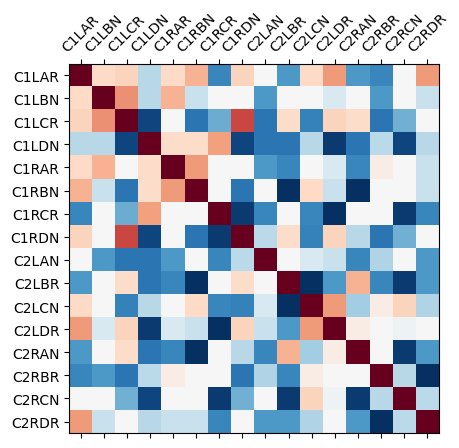

In [11]:
rdm = distance.squareform(distance.pdist(p[nodes["iteration"], :], metric="correlation"))
fig, ax = plt.subplots()
ax.matshow(rdm, cmap="RdBu")
ax.set_xticks(np.arange(len(nodes)))
ax.set_xticklabels(nodes["node"])
ax.set_yticks(np.arange(len(nodes)))
ax.set_yticklabels(nodes["node"])
ax.tick_params(axis="x", labelrotation=45)
fig.savefig(fig_dir / "rdm_feedback.pdf")

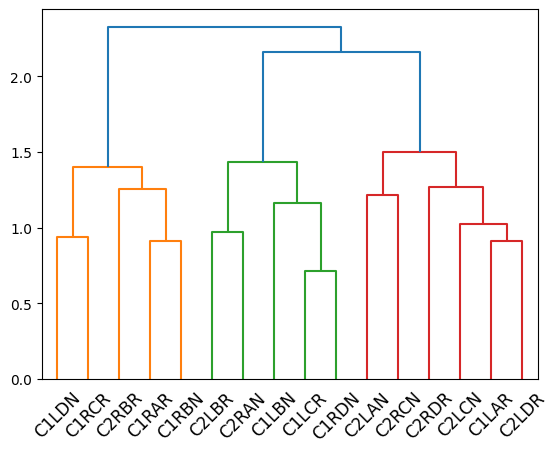

In [12]:
linkage_data = hierarchy.linkage(p[nodes["iteration"], :], method="ward", metric="euclidean")
fig, ax = plt.subplots()
hierarchy.dendrogram(linkage_data, ax=ax, labels=nodes["node"])
ax.tick_params(axis='x', labelrotation=45)

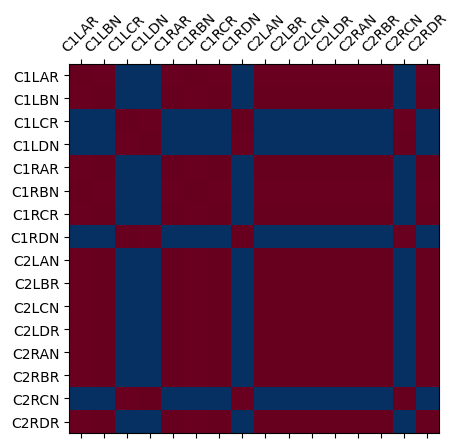

In [13]:
rdm = distance.squareform(distance.pdist(g[nodes["iteration"], :], metric="euclidean"))
fig, ax = plt.subplots()
ax.matshow(rdm, cmap="RdBu")
ax.set_xticks(np.arange(len(nodes)))
ax.set_xticklabels(nodes["node"])
ax.set_yticks(np.arange(len(nodes)))
ax.set_yticklabels(nodes["node"])
ax.tick_params(axis="x", labelrotation=45)

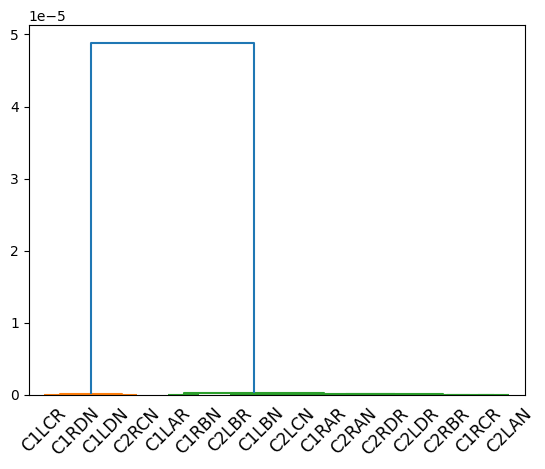

In [14]:
linkage_data = hierarchy.linkage(g[nodes["iteration"], :], method="ward", metric="euclidean")
fig, ax = plt.subplots()
hierarchy.dendrogram(linkage_data, ax=ax, labels=nodes["node"])
ax.tick_params(axis='x', labelrotation=45)